In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('netflix_customer_churn.csv')

# Let's see what we are working with
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5000, 14)


,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [2]:
print(df.isnull().sum())

customer_id               0
age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churned                   0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
dtype: int64


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   str    
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   str    
 3   subscription_type       5000 non-null   str    
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   str    
 7   device                  5000 non-null   str    
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   str    
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   str    
dtypes: float64(3), int64(4), str(7)
memory usage: 547.0

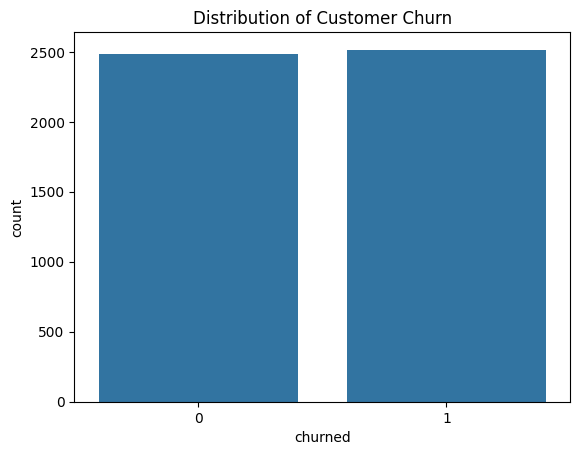

churned
1    50.3
0    49.7
Name: proportion, dtype: float64


In [7]:
# See distribution of churn
sns.countplot(data=df, x='churned')
plt.title('Distribution of Customer Churn')
plt.show()

print(df['churned'].value_counts(normalize=True) * 100)

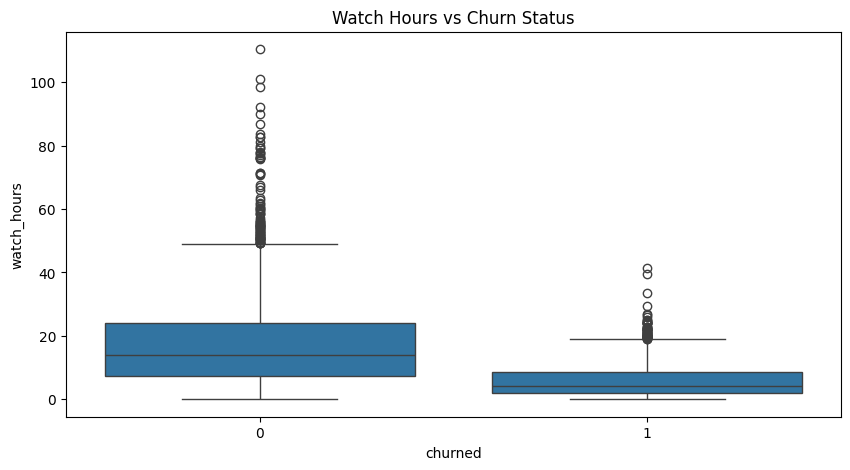

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='churned', y='watch_hours')
plt.title('Watch Hours vs Churn Status')
plt.show()

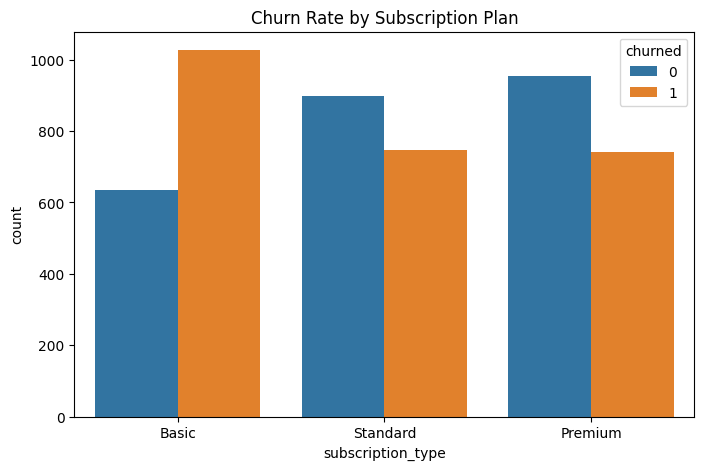

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='subscription_type', hue='churned')
plt.title('Churn Rate by Subscription Plan')
plt.show()

In [10]:
print(df.columns.tolist())

['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days', 'region', 'device', 'monthly_fee', 'churned', 'payment_method', 'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre']


In [11]:
# 1. Separate target and features
X = df.drop(columns=['customer_id', 'churned'])
y = df['churned']

# 2. Complete manual classification of all remaining columns
numerical_cols = [
    'age', 
    'watch_hours', 
    'last_login_days', 
    'monthly_fee', 
    'number_of_profiles', 
    'avg_watch_time_per_day'
]

categorical_cols = [
    'gender', 
    'subscription_type', 
    'region', 
    'device', 
    'payment_method', 
    'favorite_genre'
]

# Quick verification check
print("Total features classified:", len(numerical_cols) + len(categorical_cols)) # Should equal 12

Total features classified: 12


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Step 1: Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Build the Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Step 3: Bundle everything into a Master Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# Step 4: Fit the model
pipeline.fit(X_train, y_train)
print("Pipeline trained perfectly!")

Pipeline trained perfectly!


In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Use the trained pipeline to make predictions on the test data
y_pred = pipeline.predict(X_test)

# 2. Calculate the overall Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {accuracy * 100:.2f}%")
print("-" * 50)

# 3. Print the Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("-" * 50)

# 4. Generate the Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Overall Model Accuracy: 89.70%
--------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       498
           1       0.88      0.92      0.90       502

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000

--------------------------------------------------
Confusion Matrix:
[[437  61]
 [ 42 460]]


In [19]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameters grid we want to test
# Note the prefix 'classifier__' — this tells the pipeline to pass these settings straight to the Logistic Regression step!
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l2']  # Standard penalty supported by the default solver
}

# 2. Set up the Grid Search factory with 5-Fold Cross Validation
grid_search = GridSearchCV(
    estimator=pipeline,     # Pass your entire master pipeline here
    param_grid=param_grid,  # Pass our dictionary of settings
    cv=5,                   # 5-fold cross-validation (splits and tests data 5 times)
    scoring='accuracy',     # Find the settings that give the best overall accuracy
    n_jobs=-1               # Use all available CPU cores to speed things up
)

# 3. Run the search (this might take a few seconds because it's running 25 total combinations!)
grid_search.fit(X_train, y_train)

print("Grid Search complete!")
print("Best parameters found:", grid_search.best_params_)
print(f"Best cross-validation accuracy: {grid_search.best_score_ * 100:.2f}%")

Grid Search complete!
Best parameters found: {'classifier__C': 100, 'classifier__penalty': 'l2'}
Best cross-validation accuracy: 89.55%


c:\Users\parth\OneDrive\Desktop\DA\Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


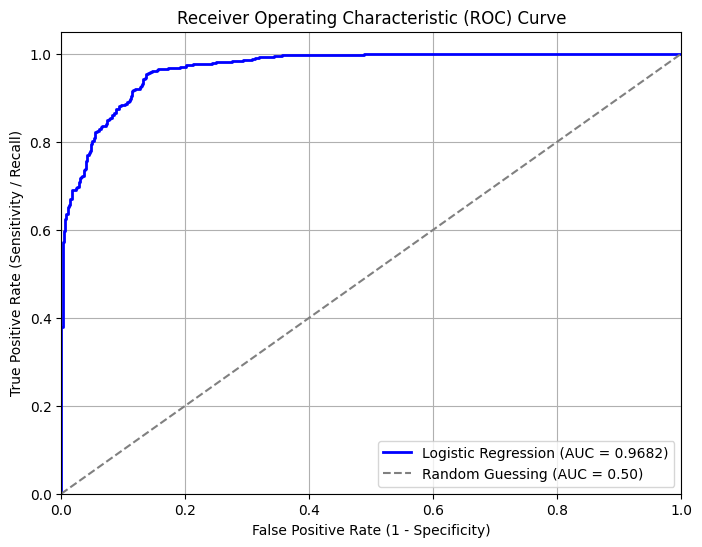

Final Model AUC Score: 0.9682


In [20]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Get the best trained pipeline estimator from your grid search
best_model = grid_search.best_estimator_

# 2. Predict probability scores for the test data
# [:, 1] grabs the probabilities for class 1 (the probability of churning)
y_probabilities = best_model.predict_proba(X_test)[:, 1]

# 3. Calculate the overall AUC score
auc_score = roc_auc_score(y_test, y_probabilities)

# 4. Generate the True Positive Rate and False Positive Rate points for the curve
fpr, tpr, thresholds = roc_curve(y_test, y_probabilities)

# 5. Plot the ROC Curve graph
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guessing (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"Final Model AUC Score: {auc_score:.4f}")

C:\Users\parth\AppData\Local\Temp\ipykernel_10416\1686988440.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Coefficient', y='Feature', palette='coolwarm')


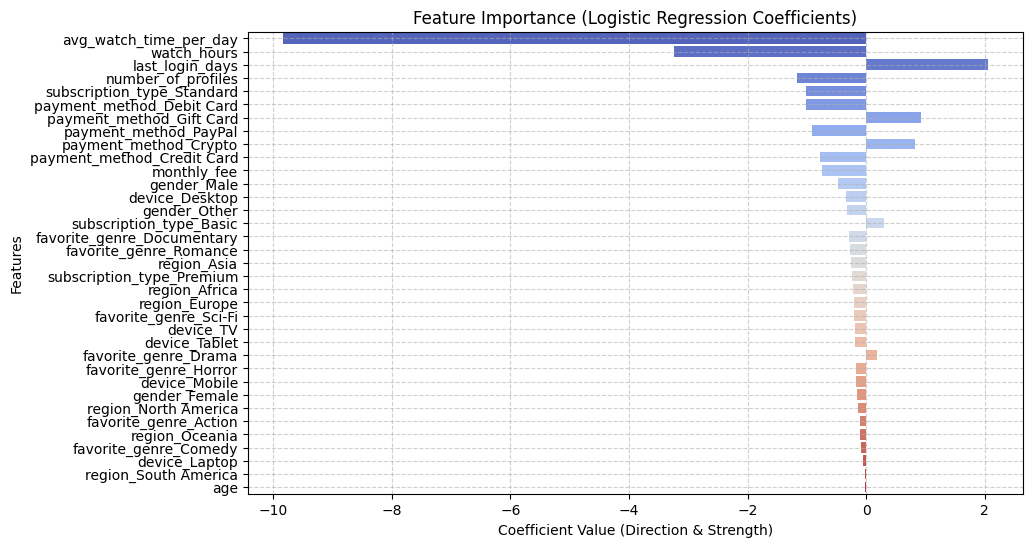

                       Feature  Coefficient
5       avg_watch_time_per_day    -9.829044
1                  watch_hours    -3.234745
2              last_login_days     2.051463
4           number_of_profiles    -1.162573
11  subscription_type_Standard    -1.016550
25   payment_method_Debit Card    -1.005792
26    payment_method_Gift Card     0.926216
27       payment_method_PayPal    -0.919567
24       payment_method_Crypto     0.831831
23  payment_method_Credit Card    -0.786418
3                  monthly_fee    -0.747972
7                  gender_Male    -0.471129
18              device_Desktop    -0.341248
8                 gender_Other    -0.324951
9      subscription_type_Basic     0.301743
30  favorite_genre_Documentary    -0.281939
33      favorite_genre_Romance    -0.276002
13                 region_Asia    -0.253358
10   subscription_type_Premium    -0.238922
12               region_Africa    -0.219800
14               region_Europe    -0.211051
34       favorite_genre_Sci-Fi  

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the trained encoder from the pipeline to see the new one-hot encoded column names
cat_encoder = best_model.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_cols).tolist()

# 2. Combine numerical column names with the newly generated categorical column names
all_features = numerical_cols + encoded_cat_cols

# 3. Grab the raw mathematical weights (coefficients) from the Logistic Regression model
coefficients = best_model.named_steps['classifier'].coef_[0]

# 4. Create a DataFrame to cleanly map features to their corresponding weights
feature_importance = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': coefficients
})

# 5. Sort by absolute magnitude to see the most influential features first
feature_importance['Absolute_Weight'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Absolute_Weight', ascending=False).drop(columns=['Absolute_Weight'])

# 6. Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value (Direction & Strength)')
plt.ylabel('Features')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(feature_importance)

In [22]:
import joblib

# Saving your hard work!
# This single file saves your scaling rules, encoding map, and model coefficients
joblib.dump(grid_search.best_estimator_, 'netflix_churn_pipeline.pkl')

['netflix_churn_pipeline.pkl']